In [1]:
import numpy as np

In [2]:

# read collected data
#bond_lengths = []
n = 26
T_asp_optimal = np.zeros((n),dtype=float)
gaps = np.zeros((n),dtype=float)
j = 0
data_file = './scripts/data_collected'
with open(data_file,'r') as file_:
    for line in file_:
        if line.startswith('#'):
            continue
        parts = line.strip().split()
        #bond_lengths.append(float(parts[0]))
        T_asp_optimal[j] = float(parts[2])
        print(float(parts[0]), T_asp_optimal[j])
        j+=1

1.5 1.2861905976452241
1.6 5.117269631368764
1.7 12.319249787309209
1.8 20.99075505816806
1.9 31.21874407506298
2.0 42.531221013786656
2.1 56.31526026563963
2.2 74.13950903258035
2.3 93.97027422338927
2.4 122.71455158384241
2.5 170.20342725525316
2.6 221.36521742517036
2.7 292.92859835948195
2.8 419.50053579626893
2.9000000000000004 542.8105389321938
3.0 753.1094737565571
3.1 1074.604571018339
3.2 1415.894570468658
3.3 1825.0657680774925
3.4000000000000004 2515.0854326763447
3.5 3394.486816113254
3.6 4865.879525009883
3.7 7099.345930251911
3.8000000000000003 9031.899703705356
3.9000000000000004 12605.697134880755
4.0 19456.460209822962


In [3]:
n_p = 11
T_asp_p =np.zeros((n_p,n),dtype=float)
data_file = './scripts/T_asp_p_collected'
j = 0
with open(data_file,'r') as file_:
    for line in file_:
        if line.startswith('#'):
            continue
        parts = line.strip().split()
        gaps[j] = float(parts[1])
        s = str(gaps[j])
        for k in range(n_p):
            T_asp_p[k,j] = float(parts[k+2])
            s += '   ' + str(T_asp_p[k,j])
        print(s)
        j+=1

0.15349219257750235   1.1727226234448394   1.1710363978960552   1.1693753726413272   1.1677399393399404   1.1661292313737484   1.16454285312868   1.1629813611183024   1.1614433569662683   1.1599289708311014   1.1584387003451722   1.1569710181127895
0.12085400934999768   4.5866945927579295   4.555037998478486   4.523753674977964   4.492820586528009   4.4623156109309665   4.4323560696875335   4.402774344678401   4.373543232689079   4.344634574357181   4.316012596023828   4.287654248168638
0.09496059270630042   11.844830360814921   11.784316031075242   11.725714616679488   11.6689554078468   11.61396929228172   11.560686085650138   11.508991312962197   11.458804039381963   11.410047353116953   11.362696554083515   11.316660280445015
0.07448900105713108   19.86723686581349   19.751283702459457   19.64238641380895   19.539561777538008   19.44263936164055   19.35134081304541   19.26574421043726   19.185815933235233   19.111020217938727   19.04081103930048   18.975539580312784
0.0583487532284

In [4]:
# optimal data for 3.5A
bond_length =3.5
asp_schedule_dir = './data/' +str(bond_length) + '/delta_schedules/opt'
asp_optimal_dir = './data/' +str(bond_length) + '/delta_schedules/opt/asp'
t_list_optimal = []
s_list_optimal = []
with open(asp_schedule_dir + '/schedule','r') as file_:
    for line in file_:
        if not line.strip():
            continue
        if line.startswith('#'):
            continue
        ls = line.split()
        t_list_optimal.append(float(ls[0]))
        s_list_optimal.append(float(ls[1]))

tf_grid_optimal = []
fidelity_optimal = []

with open(asp_optimal_dir + '/fidelity','r') as file_:
    for line in file_:
        if not line.strip():
            continue
        if line.startswith('#'):
            continue
        ls = line.split()
        tf_grid_optimal.append(float(ls[0]))
        fidelity_optimal.append(float(ls[1]))
        #print(ls[0], ls[1])


In [5]:
bond_length =3.5
p_list = np.linspace(1.0, 2.0, num=n_p)
ntau = 21
t_list_p = np.zeros((n_p,ntau),dtype=float) 
s_list_p = np.zeros((n_p,ntau),dtype=float)

n_T = 31
tf_grid_p = np.zeros((n_p,n_T), dtype=float)
fidelity_p = np.zeros((n_p,n_T), dtype=float)


for i_p in range(n_p):
    p = p_list[i_p]
    asp_schedule_dir = './data/' +str(bond_length) + '/delta_schedules/{p:.1f}'.format(p=p)
    asp_dir = asp_schedule_dir + '/asp'
    j = 0
    with open(asp_schedule_dir + '/schedule','r') as file_:
        for line in file_:
            if not line.strip():
                continue
            if line.startswith('#'):
                continue
            ls = line.split()
            t_list_p[i_p,j]=float(ls[0])
            s_list_p[i_p,j]=float(ls[1])
            #print(t_list_p[i_p,j], s_list_p[i_p,j])
            j+=1

    j = 0
    with open(asp_dir + '/fidelity','r') as file_:
        for line in file_:
            if not line.strip():
                continue
            if line.startswith('#'):
                continue
            ls = line.split()
            tf_grid_p[i_p,j]=float(ls[0])
            fidelity_p[i_p,j]=float(ls[1])
            #print(tf_grid_p[i_p,j], fidelity_p[i_p,j])
            j+=1

In [6]:
print(gaps, T_asp_p[0,:])

[1.53492193e-01 1.20854009e-01 9.49605927e-02 7.44890011e-02
 5.83487532e-02 4.56563964e-02 3.56603490e-02 2.78065909e-02
 2.16267982e-02 1.67652675e-02 1.29744193e-02 9.94671225e-03
 7.66752867e-03 5.78388394e-03 4.37242306e-03 3.34127930e-03
 2.61903587e-03 2.09180368e-03 1.54508037e-03 1.13382055e-03
 8.26475820e-04 5.98272447e-04 4.29978585e-04 3.06710848e-04
 2.17081496e-04 1.52381781e-04] [1.17272262e+00 4.58669459e+00 1.18448304e+01 1.98672369e+01
 2.96880784e+01 4.07689347e+01 5.45110937e+01 7.31950251e+01
 1.01822799e+02 1.45417556e+02 2.00937955e+02 2.78487949e+02
 3.88587834e+02 5.41748458e+02 7.65062808e+02 1.07284246e+03
 1.51982672e+03 2.16392921e+03 3.11843903e+03 4.51520001e+03
 6.56427581e+03 9.60420366e+03 1.42378369e+04 2.09461326e+04
 3.11182154e+04 4.59152894e+04]


<Figure size 2031.5x1625.2 with 0 Axes>

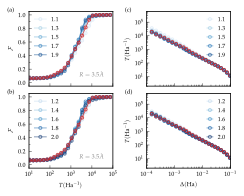

In [7]:
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('pdf','svg')
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import LogLocator
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size"  : 6
})

# Figure size: 2 columns × width_col, height = width_col/2 (in inches)
cm        = 1.0 / 2.54
width_col = 8.6 * cm
width     = width_col 
height    = width_col / 2 * 1.6
plt.figure(figsize=(width,height),dpi=600)

# Create figure and 4 horizontal panels with default padding
fig, axes = plt.subplots(2, 2, figsize=(width, height))

# Work in panel (a)
# exact schedule

marker_style_ref = dict(marker='',linestyle='dashed',color='black',alpha=0.9,linewidth=0.8)

marker_style_1   = dict(marker='o', markersize=3, linestyle='solid', color='tab:red', alpha=0.8,  fillstyle='none')
marker_style_1_sm   = dict(marker='o', markersize=3, linestyle='solid', color='tab:red', alpha=0.8,  fillstyle='none')
marker_style_1_p   = dict(marker='o', markersize=3, linestyle='', color='tab:red', alpha=0.8,  fillstyle='none')
marker_style_1_l   = dict(marker='', linestyle='solid', color='tab:red', alpha=0.8,  fillstyle='none')
marker_style_1_ref = dict(marker='',linestyle='dashed',color='tab:red',alpha=0.6,linewidth=0.6)

marker_style_2   = dict(marker='o', markersize=3, linestyle='solid', color='black', alpha=0.8,  fillstyle='none')
marker_style_2_sm   = dict(marker='o', markersize=3, linestyle='solid', color='black', alpha=0.8,  fillstyle='none')
marker_style_2_p   = dict(marker='o', markersize=3, linestyle='', color='black', alpha=0.8,  fillstyle='none')
marker_style_2_l   = dict(marker='', linestyle='solid', color='black', alpha=0.8,  fillstyle='none')
marker_style_2_ref = dict(marker='',linestyle='dashed',color='black',alpha=0.6,linewidth=0.6)

marker_style_3   = dict(marker='o', markersize=3, linestyle='solid', color='mediumblue', alpha=0.8,  fillstyle='none')
marker_style_3_sm   = dict(marker='o', markersize=3, linestyle='solid', color='mediumblue', alpha=0.8,  fillstyle='none')
marker_style_3_p   = dict(marker='o', markersize=3, linestyle='', color='mediumblue', alpha=0.8,  fillstyle='none')
marker_style_3_l   = dict(marker='', linestyle='solid', color='mediumblue', alpha=0.8,  fillstyle='none')
marker_style_3_ref = dict(marker='',linestyle='dashed',color='mediumblue',alpha=0.6,linewidth=0.6)

cmap = plt.get_cmap('Blues') 


# Work in panel (b) - fidelity
axis = axes[0,0]


x_min    =  10
x_max    =  1e5

y_min    =  -0.05
y_max    =  +1.05


axis.set_xlim(x_min,x_max)
axis.set_ylim(y_min,y_max)
# setup labels
axis.text(0.6, 0.13, r'$R=3.5\AA$',transform=axis.transAxes,color='gray')
axis.text(-0.26, 1, r'(a)',transform=axis.transAxes)
#axis.set_xlabel(r'$T(\textrm{Ha}^{-1})$')
axis.set_ylabel(r'$\mathcal{F}$')
# setup tics
axis.tick_params(axis='x', which='major', direction='in', length=2.8, width=0.4)
axis.tick_params(axis='x', which='minor', direction='in', length=1.4, width=0.4)
axis.tick_params(axis='y', which='major', direction='in', length=2.8, width=0.4)
axis.tick_params(axis='y', which='minor', direction='in', length=1.4, width=0.4)
#axis.xaxis.set_major_locator(ticker.MultipleLocator(0.2))
#axis.xaxis.set_major_formatter('{x:0.1f}')
#axis.xaxis.set_minor_locator(ticker.MultipleLocator(0.1))
axis.set_xscale('log')

axis.xaxis.set_major_locator(LogLocator(base=10.0, numticks=6))


axis.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
axis.yaxis.set_major_formatter('{x:3.1f}')
axis.yaxis.set_minor_locator(ticker.MultipleLocator(0.1))

#axis.plot(tf_grid_linear,fidelity_linear, label =r'$s_l$', lw=0.8, **marker_style_2_sm)

#axis.plot(tf_grid_optimal,[-1]*len(fidelity_optimal), label =r'$\hat{s}_c$', lw=0.8, **marker_style_1_sm)
for i_p in range(1,10,2):
    color_val = (i_p + 1) / n_p
    marker_style  = dict(marker='o', markersize=3, linestyle='solid', color=cmap(color_val), alpha=0.6, fillstyle='none')
    axis.plot(tf_grid_p[i_p,:],fidelity_p[i_p,:], label =r'${p:.1f}$'.format(p=p_list[i_p]), lw=0.8, **marker_style)

axis.plot(tf_grid_optimal,fidelity_optimal, label =r'', lw=0.8, **marker_style_1_sm)

axis.legend(loc='upper left',frameon=False)

plt.setp(axis.get_xticklabels(), visible=False)

# Work in panel (b)
axis = axes[1,0]


x_min    =  10
x_max    =  1e5

y_min    =  -0.05
y_max    =  +1.05


axis.set_xlim(x_min,x_max)
axis.set_ylim(y_min,y_max)
# setup labels
axis.text(0.6, 0.13, r'$R=3.5\AA$',transform=axis.transAxes,color='gray')
axis.text(-0.26, 1, r'(b)',transform=axis.transAxes)
axis.set_xlabel(r'$T(\textrm{Ha}^{-1})$')
axis.set_ylabel(r'$\mathcal{F}$')
# setup tics
axis.tick_params(axis='x', which='major', direction='in', length=2.8, width=0.4)
axis.tick_params(axis='x', which='minor', direction='in', length=1.4, width=0.4)
axis.tick_params(axis='y', which='major', direction='in', length=2.8, width=0.4)
axis.tick_params(axis='y', which='minor', direction='in', length=1.4, width=0.4)
#axis.xaxis.set_major_locator(ticker.MultipleLocator(0.2))
#axis.xaxis.set_major_formatter('{x:0.1f}')
#axis.xaxis.set_minor_locator(ticker.MultipleLocator(0.1))
axis.set_xscale('log')

axis.xaxis.set_major_locator(LogLocator(base=10.0, numticks=6))


axis.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
axis.yaxis.set_major_formatter('{x:3.1f}')
axis.yaxis.set_minor_locator(ticker.MultipleLocator(0.1))

#axis.plot(tf_grid_linear,fidelity_linear, label =r'$s_l$', lw=0.8, **marker_style_2_sm)

#axis.plot(tf_grid_optimal,[-1]*len(fidelity_optimal), label =r'$\hat{s}_c$', lw=0.8, **marker_style_1_sm)
for i_p in range(2,11,2):
    color_val = (i_p + 1) / n_p
    marker_style  = dict(marker='o', markersize=3, linestyle='solid', color=cmap(color_val), alpha=0.6, fillstyle='none')
    axis.plot(tf_grid_p[i_p,:],fidelity_p[i_p,:], label =r'${p:.1f}$'.format(p=p_list[i_p]), lw=0.8, **marker_style)

axis.plot(tf_grid_optimal,fidelity_optimal, label =r'', lw=0.8, **marker_style_1_sm)

axis.legend(loc='upper left',frameon=False)


#
#
## Work in panel (d) - T_asp vs gap
axis = axes[0,1]

y_min    =  2
y_max    =  600000

x_min    =  0.0001
x_max    =  0.1


axis.set_xlim(x_min,x_max)
axis.set_ylim(y_min,y_max)
# setup labels
axis.text(-0.26, 1, r'(c)',transform=axis.transAxes)
#axis.set_xlabel(r'$\Delta(\textrm{Ha})$')
axis.set_ylabel(r'$T(\textrm{Ha}^{-1})$')
# setup tics
axis.tick_params(axis='x', which='major', direction='in', length=2.8, width=0.4)
axis.tick_params(axis='x', which='minor', direction='in', length=1.4, width=0.4)
axis.tick_params(axis='y', which='major', direction='in', length=2.8, width=0.4)
axis.tick_params(axis='y', which='minor', direction='in', length=1.4, width=0.4)
#axis.xaxis.set_major_locator(ticker.MultipleLocator(0.2))
#axis.xaxis.set_major_formatter('{x:0.1f}')
#axis.xaxis.set_minor_locator(ticker.MultipleLocator(0.1))
axis.set_xscale('log')
axis.set_yscale('log')

axis.yaxis.set_major_locator(LogLocator(base=10.0, numticks=10))
axis.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=12))


#axis.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
#axis.yaxis.set_major_formatter('{x:3.1f}')
#axis.yaxis.set_minor_locator(ticker.MultipleLocator(0.1))

#axis.plot(gaps,[-1] * len(T_asp_optimal),
#          label =r'$T[\hat{s}_c]$', **marker_style_1_p)
for i_p in range(1,10,2):
    color_val = (i_p + 1) / n_p
    marker_style  = dict(marker='o', markersize=3, linestyle='solid', color=cmap(color_val), fillstyle='none')
    axis.plot(gaps,T_asp_p[i_p,:], label =r'${p:.1f}$'.format(p=p_list[i_p]), alpha=0.6, lw=0.8, **marker_style)

axis.plot(gaps,T_asp_optimal,
          label ='', **marker_style_1_p)




axis.legend(loc='upper right',handlelength=1.0,frameon=False)

plt.setp(axis.get_xticklabels(), visible=False)
#
#
## Work in panel (e) - T_asp vs gap
axis = axes[1,1]

y_min    =  2
y_max    =  600000

x_min    =  0.0001
x_max    =  0.1


axis.set_xlim(x_min,x_max)
axis.set_ylim(y_min,y_max)
# setup labels
axis.text(-0.26, 1, r'(d)',transform=axis.transAxes)
axis.set_xlabel(r'$\Delta(\textrm{Ha})$')
axis.set_ylabel(r'$T(\textrm{Ha}^{-1})$')
# setup tics
axis.tick_params(axis='x', which='major', direction='in', length=2.8, width=0.4)
axis.tick_params(axis='x', which='minor', direction='in', length=1.4, width=0.4)
axis.tick_params(axis='y', which='major', direction='in', length=2.8, width=0.4)
axis.tick_params(axis='y', which='minor', direction='in', length=1.4, width=0.4)
#axis.xaxis.set_major_locator(ticker.MultipleLocator(0.2))
#axis.xaxis.set_major_formatter('{x:0.1f}')
#axis.xaxis.set_minor_locator(ticker.MultipleLocator(0.1))
axis.set_xscale('log')
axis.set_yscale('log')

axis.yaxis.set_major_locator(LogLocator(base=10.0, numticks=10))
axis.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=12))


#axis.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
#axis.yaxis.set_major_formatter('{x:3.1f}')
#axis.yaxis.set_minor_locator(ticker.MultipleLocator(0.1))

#axis.plot(gaps,[-1] * len(T_asp_optimal),
#          label =r'$T[\hat{s}_c]$', **marker_style_1_p)
for i_p in range(2,11,2):
    color_val = (i_p + 1) / n_p
    marker_style  = dict(marker='o', markersize=3, linestyle='solid', color=cmap(color_val), fillstyle='none')
    axis.plot(gaps,T_asp_p[i_p,:], label =r'${p:.1f}$'.format(p=p_list[i_p]), alpha=0.6, lw=0.8, **marker_style)

axis.plot(gaps,T_asp_optimal,
          label =r'', **marker_style_1_p)




axis.legend(loc='upper right',handlelength=1.0,frameon=False)

#

#
#
plt.tight_layout()
plt.subplots_adjust(hspace=0.1)
plt.savefig('figS2.pdf')
#